In [1]:
x=1

In [2]:
import scanpy as sc
import pandas as pd
import decoupler as dc

from sklearn.metrics import classification_report

In [3]:
adata = sc.read('/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/snakemake/hyperparam/data/pp/hlca_hvg_pearson.h5ad')
adata

AnnData object with n_obs × n_vars = 2149684 × 2000
    obs: "3'_or_5'", 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ancestry', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'assay', 'cause_of_death', 'cell_type', 'core_or_extension', 'dataset', 'development_stage', 'disease', 'donor_id', 'fresh_or_frozen', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'original_ann_level_1', 'original_ann_level_2', 'original_ann_level_3', 'original_ann_level_4', 'original_ann_level_5', 'original_ann_nonharmonized', 'reannotation_type', 'sample', 'scanvi_label', 'sequencing_platform', 'sex', 'smoking_status', 'study', 'subject_type', 'suspension_type', 'tissue', 'tissue_coarse_unharmonized', 'tissue_detailed_unharmonized', 'tissue_dissociation_protocol', 'tissue_level_2', 'tissue_level_3', 'tissue_sampling_method', 'total_counts', 'transf_ann_level_1_label', 'transf_ann_l

In [4]:
adata.X.data

array([1., 5., 1., ..., 1., 2., 3.], dtype=float32)

In [5]:
DONOR = 'sample'
CONDITION = 'lung_condition_coarse'

# Create pseudobulks

In [6]:
# Get pseudo-bulk profile
adata_ = dc.get_pseudobulk(adata, sample_col=DONOR, groups_col=None, min_prop=-1, min_smpls=0, min_cells=0, min_counts=0)
adata_

View of AnnData object with n_obs × n_vars = 709 × 2000
    obs: "3'_or_5'", 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ancestry', 'assay', 'cause_of_death', 'core_or_extension', 'dataset', 'development_stage', 'disease', 'donor_id', 'fresh_or_frozen', 'lung_condition', 'mixed_ancestry', 'sample', 'sequencing_platform', 'sex', 'smoking_status', 'study', 'subject_type', 'suspension_type', 'tissue', 'tissue_coarse_unharmonized', 'tissue_detailed_unharmonized', 'tissue_dissociation_protocol', 'tissue_level_2', 'tissue_level_3', 'tissue_sampling_method', 'lung_condition_coarse', 'split0', 'split1', 'split2', 'split3', 'split4'

In [7]:
sc.pp.normalize_total(adata_, target_sum=1e4)
sc.pp.log1p(adata_)

/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


# Multiclass regression

In [8]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from scipy.special import softmax
onehot_encoder = OneHotEncoder(sparse=False)
from scipy.special import logsumexp

In [9]:
def loss(X, Y, W):
    """
    Y: onehot encoded
    """
    Z = - X @ W
    N = X.shape[0]
    loss = 1/N * (np.trace(X @ W @ Y.T) + np.sum(logsumexp(Z, axis=1)))
    return loss

def gradient(X, Y, W, mu):
    """
    Y: onehot encoded 
    """
    Z = - X @ W
    P = softmax(Z, axis=1)
    N = X.shape[0]
    gd = 1/N * (X.T @ (Y - P)) + 2 * mu * W
    return gd

def gradient_descent(X, Y, max_iter=2000, eta=0.1, mu=0.01):
    """
    Very basic gradient descent algorithm with fixed eta and mu
    """
    Y_onehot = onehot_encoder.fit_transform(Y.reshape(-1,1))
    W = np.zeros((X.shape[1], Y_onehot.shape[1]))
    step = 0
    step_lst = [] 
    loss_lst = []
    W_lst = []
 
    while step < max_iter:
        step += 1
        W -= eta * gradient(X, Y_onehot, W, mu)
        step_lst.append(step)
        W_lst.append(W)
        loss_lst.append(loss(X, Y_onehot, W))

    df = pd.DataFrame({
        'step': step_lst, 
        'loss': loss_lst
    })
    return df, W

class Multiclass:
    def fit(self, X, Y):
        self.loss_steps, self.W = gradient_descent(X, Y)

    def loss_plot(self):
        return self.loss_steps.plot(
            x='step', 
            y='loss',
            xlabel='step',
            ylabel='loss'
        )

    def predict(self, H):
        Z = - H @ self.W
        P = softmax(Z, axis=1)
        return np.argmax(P, axis=1)

In [10]:
adata_.obs[CONDITION] = adata_.obs[CONDITION].astype('category')

In [11]:
val_accuracies = []
val_avg = []

for i in range(5):
    print(f'Processing split = {i}...')
    df = adata.obs[[f'split{i}', DONOR]].drop_duplicates()
    train = list(df[df[f'split{i}'] == 'train'][DONOR])
    val = list(df[df[f'split{i}'] == 'val'][DONOR])
    # train data
    x = pd.DataFrame(adata_[adata_.obs_names.isin(train)].X).to_numpy()
    num_of_classes = len(adata_.obs[CONDITION].cat.categories)
    y = adata_[adata_.obs_names.isin(train)].obs[CONDITION].cat.rename_categories(list(range(num_of_classes)))
    y = y.to_numpy()
    print("Train shapes:")
    print(f"x.shape = {x.shape}")
    print(f"y.shape = {y.shape}")
    # val data
    x_val = pd.DataFrame(adata_[adata_.obs_names.isin(val)].X).to_numpy()
    y_val = adata_[adata_.obs_names.isin(val)].obs[CONDITION].cat.rename_categories(list(range(num_of_classes)))
    y_val = y_val.to_numpy()
    print("Val shapes:")
    print(f"x_val.shape = {x_val.shape}")
    print(f"y_val.shape = {y_val.shape}")
    # fit
    X = x
    Y = y
    model = Multiclass()
    model.fit(X, Y)
    print(f'Train accuracy = {np.sum(model.predict(X) == Y)/len(Y)}.')
    y_pred = model.predict(x_val)
    
    df = classification_report(y_val, y_pred, output_dict=True)
    df = pd.DataFrame(df).T
        
    print('class report')
    print(df)
    
    print(f'Val accuracy = {df["f1-score"]["accuracy"]}.')
    print('===========================')
    
    val_accuracies.append(df["f1-score"]["accuracy"])
    val_avg.append(df["f1-score"]["weighted avg"])

print(f"Mean validation accuracy across 5 CV splits for a multiclass regression model = {np.mean(np.array(val_accuracies))}.")
print(f"Mean validation weighted avg across 5 CV splits for a multiclass regression model = {np.mean(np.array(val_avg))}.")

Processing split = 0...
Train shapes:
x.shape = (567, 2000)
y.shape = (567,)
Val shapes:
x_val.shape = (142, 2000)
y_val.shape = (142,)
Train accuracy = 1.0.
class report
              precision    recall  f1-score     support
0              1.000000  0.666667  0.800000    3.000000
1              0.888889  1.000000  0.941176    8.000000
2              0.928571  1.000000  0.962963   13.000000
3              0.750000  1.000000  0.857143    6.000000
4              0.666667  1.000000  0.800000    4.000000
5              0.962963  0.928571  0.945455   84.000000
6              0.166667  0.333333  0.222222    3.000000
7              1.000000  0.736842  0.848485   19.000000
8              1.000000  1.000000  1.000000    2.000000
accuracy       0.901408  0.901408  0.901408    0.901408
macro avg      0.818195  0.851713  0.819716  142.000000
weighted avg   0.927733  0.901408  0.908429  142.000000
Val accuracy = 0.9014084507042254.
Processing split = 1...
Train shapes:
x.shape = (567, 2000)
y.shap

/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels w

Train accuracy = 0.6313932980599647.
class report
              precision    recall  f1-score     support
0              0.000000  0.000000  0.000000    4.000000
1              0.000000  0.000000  0.000000    4.000000
2              1.000000  0.071429  0.133333   14.000000
3              1.000000  0.571429  0.727273    7.000000
4              1.000000  0.250000  0.400000    4.000000
5              0.671642  1.000000  0.803571   90.000000
6              0.000000  0.000000  0.000000    4.000000
7              0.000000  0.000000  0.000000   12.000000
8              0.500000  0.333333  0.400000    3.000000
accuracy       0.683099  0.683099  0.683099    0.683099
macro avg      0.463516  0.247354  0.273797  142.000000
weighted avg   0.612308  0.683099  0.578021  142.000000
Val accuracy = 0.6830985915492958.
Processing split = 3...
Train shapes:
x.shape = (567, 2000)
y.shape = (567,)
Val shapes:
x_val.shape = (142, 2000)
y_val.shape = (142,)


/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels w

Train accuracy = 0.9858906525573192.
class report
              precision    recall  f1-score     support
0              0.777778  1.000000  0.875000    7.000000
1              0.750000  1.000000  0.857143    3.000000
2              0.866667  0.812500  0.838710   16.000000
3              0.937500  1.000000  0.967742   15.000000
4              0.666667  1.000000  0.800000    2.000000
5              0.945946  0.886076  0.915033   79.000000
6              0.333333  0.333333  0.333333    3.000000
7              0.800000  0.857143  0.827586   14.000000
8              0.333333  0.333333  0.333333    3.000000
accuracy       0.873239  0.873239  0.873239    0.873239
macro avg      0.712358  0.802487  0.749764  142.000000
weighted avg   0.879484  0.873239  0.873984  142.000000
Val accuracy = 0.8732394366197183.
Processing split = 4...
Train shapes:
x.shape = (568, 2000)
y.shape = (568,)
Val shapes:
x_val.shape = (141, 2000)
y_val.shape = (141,)
Train accuracy = 0.9982394366197183.
class report
 

# NN

In [16]:
import seaborn as sns
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from random import sample
import math
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.preprocessing import MinMaxScaler    
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [17]:
class ClassifierDataset(Dataset):
    
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data
        
    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]
        
    def __len__ (self):
        return len(self.X_data)

In [18]:
class MulticlassClassification(nn.Module):
    def __init__(self, num_feature, num_class):
        super(MulticlassClassification, self).__init__()
        
        self.layer_1 = nn.Linear(num_feature, 64)
        self.layer_out = nn.Linear(64, num_class) 
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)
        self.batchnorm1 = nn.BatchNorm1d(64)
        
    def forward(self, x):
        x = self.layer_1(x)
        x = self.batchnorm1(x)
        x = self.relu(x)
        
        x = self.layer_out(x)
        
        return x

In [19]:
def multi_acc(y_pred, y_test):
    y_pred_softmax = torch.log_softmax(y_pred, dim = 1)
    _, y_pred_tags = torch.max(y_pred_softmax, dim = 1)    
    
    correct_pred = (y_pred_tags == y_test).float()
    acc = correct_pred.sum() / len(correct_pred)
    
    acc = torch.round(acc * 100)
    
    return acc

In [20]:
adata_.obs[CONDITION] = adata_.obs[CONDITION].astype('category')

In [21]:
EPOCHS = 200
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
NUM_FEATURES = adata_.shape[1]
NUM_CLASSES = len(adata_.obs[CONDITION].cat.categories)
TRAIN_FRACTION = 0.8

Processing split = 0...
Train shapes:
x.shape = (567, 2000)
y.shape = (567,)
Val shapes:
x_val.shape = (142, 2000)
y_val.shape = (142,)
Begin training.


  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 200: | Train Loss: 0.01164 | Val Loss: 0.24970 | Train Acc: 100.000| Val Acc: 92.920
class report
              precision    recall  f1-score     support
0              1.000000  0.666667  0.800000    3.000000
1              1.000000  1.000000  1.000000    8.000000
2              0.866667  1.000000  0.928571   13.000000
3              1.000000  1.000000  1.000000    6.000000
4              1.000000  1.000000  1.000000    4.000000
5              0.965517  1.000000  0.982456   84.000000
6              0.166667  0.333333  0.222222    3.000000
7              1.000000  0.684211  0.812500   19.000000
8              1.000000  0.500000  0.666667    2.000000
accuracy       0.929577  0.929577  0.929577    0.929577
macro avg      0.888761  0.798246  0.823602  142.000000
weighted avg   0.949790  0.929577  0.932643  142.000000
Accuracy on the test set = 0.9295774647887324.
Processing split = 1...
Train shapes:
x.shape = (567, 2000)
y.shape = (567,)
Val shapes:
x_val.shape = (142, 2000)
y_val.

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 200: | Train Loss: 0.01096 | Val Loss: 0.27378 | Train Acc: 100.000| Val Acc: 91.150
class report
              precision    recall  f1-score     support
0              1.000000  1.000000  1.000000    4.000000
1              0.800000  1.000000  0.888889    4.000000
2              0.916667  0.785714  0.846154   14.000000
3              0.600000  0.600000  0.600000    5.000000
4              1.000000  1.000000  1.000000    3.000000
5              0.977778  0.956522  0.967033   92.000000
6              1.000000  0.142857  0.250000    7.000000
7              0.666667  1.000000  0.800000   12.000000
8              0.250000  1.000000  0.400000    1.000000
accuracy       0.894366  0.894366  0.894366    0.894366
macro avg      0.801235  0.831677  0.750231  142.000000
weighted avg   0.924218  0.894366  0.888160  142.000000
Accuracy on the test set = 0.8943661971830986.
Processing split = 2...
Train shapes:
x.shape = (567, 2000)
y.shape = (567,)
Val shapes:
x_val.shape = (142, 2000)
y_val.

...

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 200: | Train Loss: 0.01186 | Val Loss: 0.23433 | Train Acc: 100.000| Val Acc: 92.920
class report
              precision    recall  f1-score     support
0              0.857143  0.857143  0.857143    7.000000
1              0.750000  1.000000  0.857143    3.000000
2              0.875000  0.875000  0.875000   16.000000
3              1.000000  0.866667  0.928571   15.000000
4              0.500000  0.500000  0.500000    2.000000
5              0.915663  0.962025  0.938272   79.000000
6              1.000000  0.333333  0.500000    3.000000
7              0.866667  0.928571  0.896552   14.000000
8              0.000000  0.000000  0.000000    3.000000
accuracy       0.894366  0.894366  0.894366    0.894366
macro avg      0.751608  0.702527  0.705853  142.000000
weighted avg   0.885357  0.894366  0.885036  142.000000
Accuracy on the test set = 0.8943661971830986.
Processing split = 4...
Train shapes:
x.shape = (568, 2000)
y.shape = (568,)
Val shapes:
x_val.shape = (141, 2000)
y_val.

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 200: | Train Loss: 0.01177 | Val Loss: 0.28086 | Train Acc: 100.000| Val Acc: 94.690
class report
              precision    recall  f1-score     support
0              1.000000  0.750000  0.857143    4.000000
1              1.000000  1.000000  1.000000    5.000000
2              0.761905  1.000000  0.864865   16.000000
3              1.000000  0.818182  0.900000   11.000000
4              1.000000  1.000000  1.000000    5.000000
5              0.951807  0.975309  0.963415   81.000000
6              1.000000  0.600000  0.750000    5.000000
7              0.750000  0.900000  0.818182   10.000000
8              0.000000  0.000000  0.000000    4.000000
accuracy       0.914894  0.914894  0.914894    0.914894
macro avg      0.829301  0.782610  0.794845  141.000000
weighted avg   0.899198  0.914894  0.901665  141.000000
Accuracy on the test set = 0.9148936170212766.
Mean validation accuracy across 5 CV splits for a NN model = 0.909739286784537.
Mean validation weighted avg across 5 CV 

/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels w

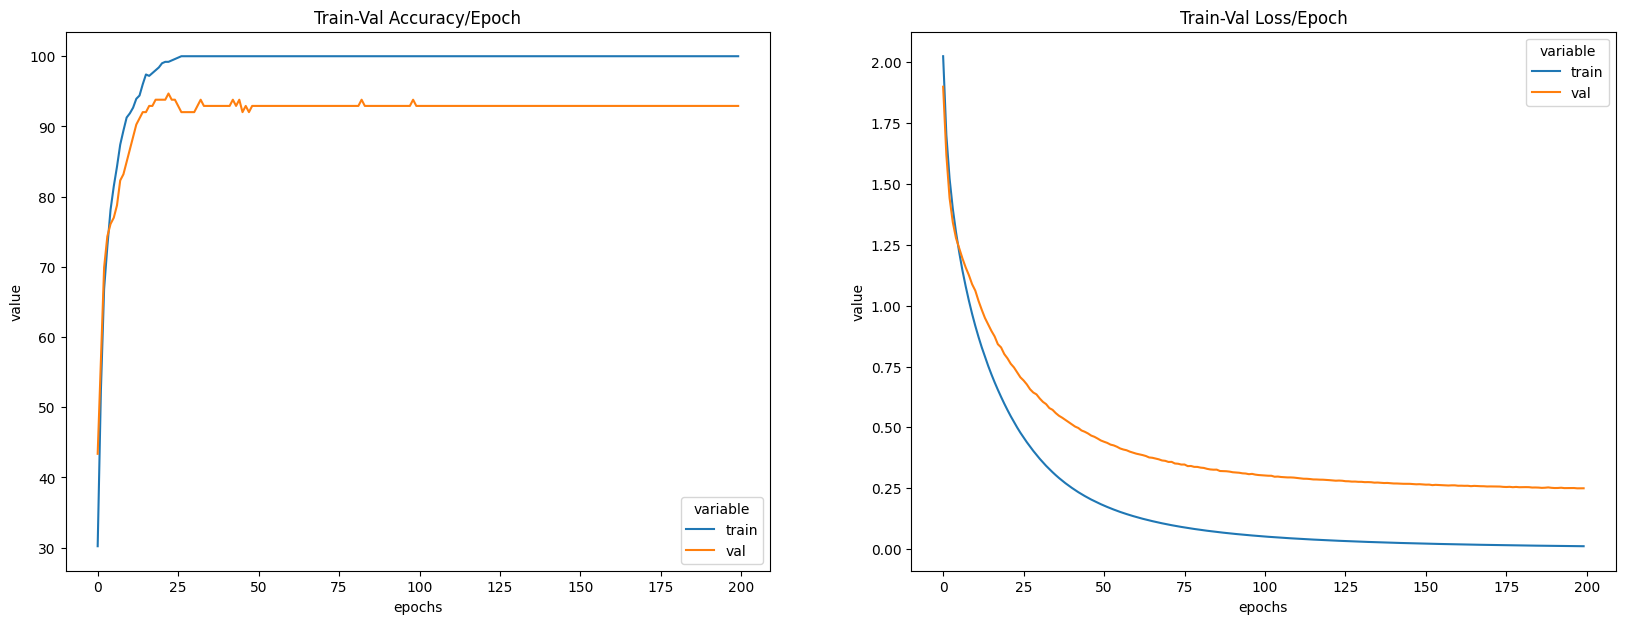

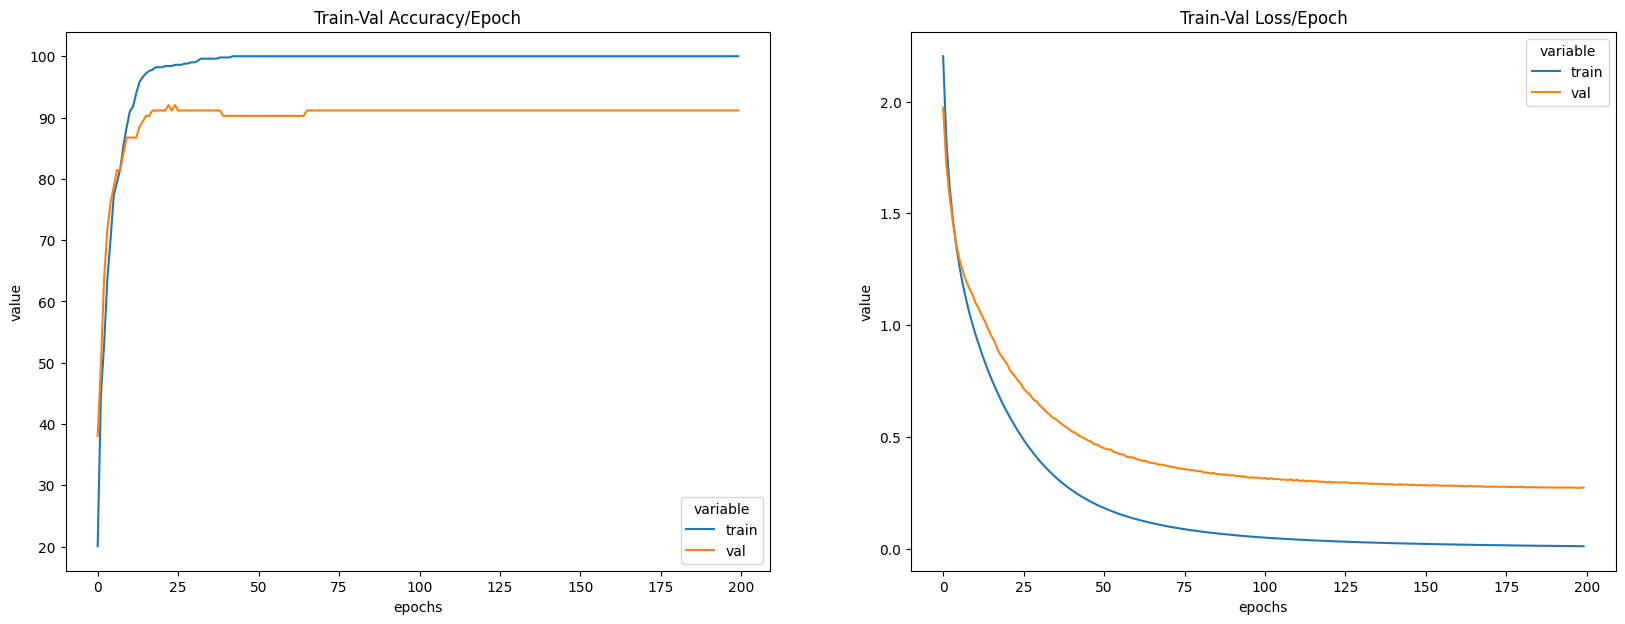

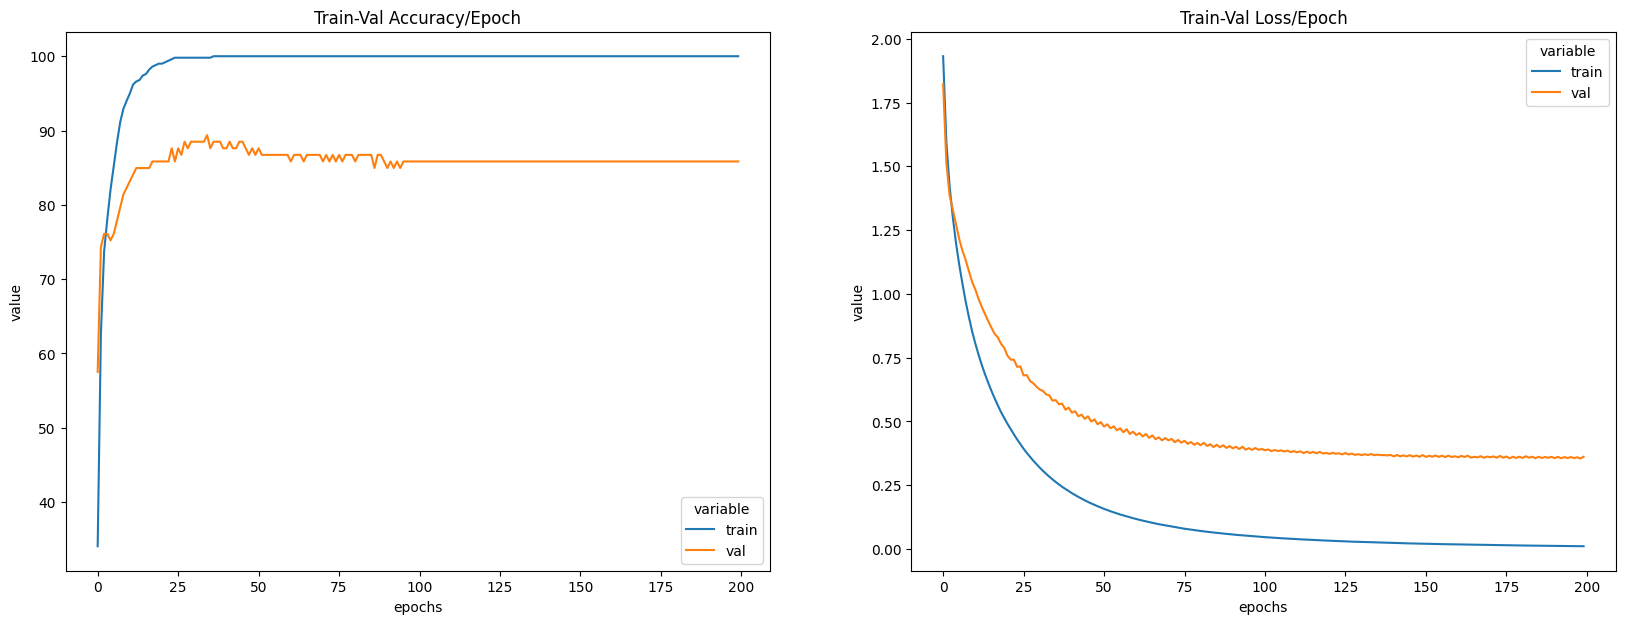

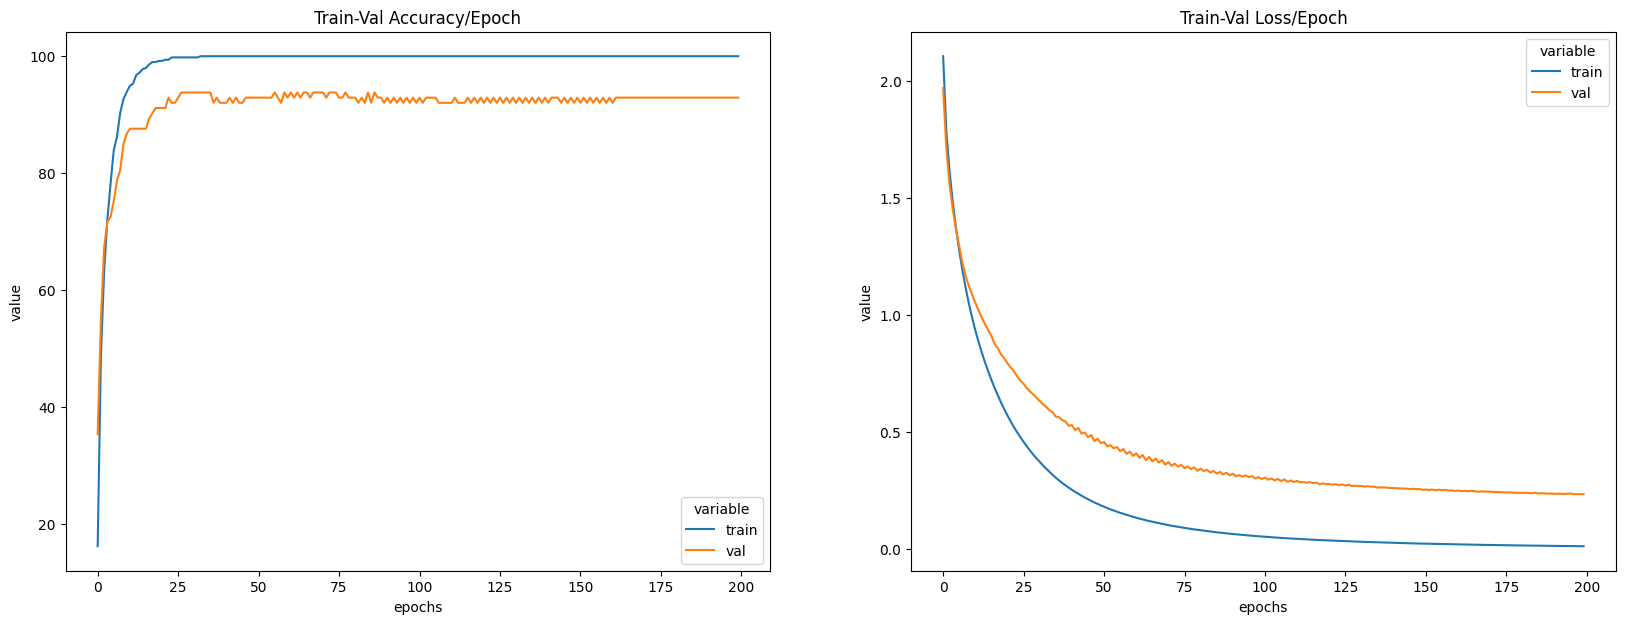

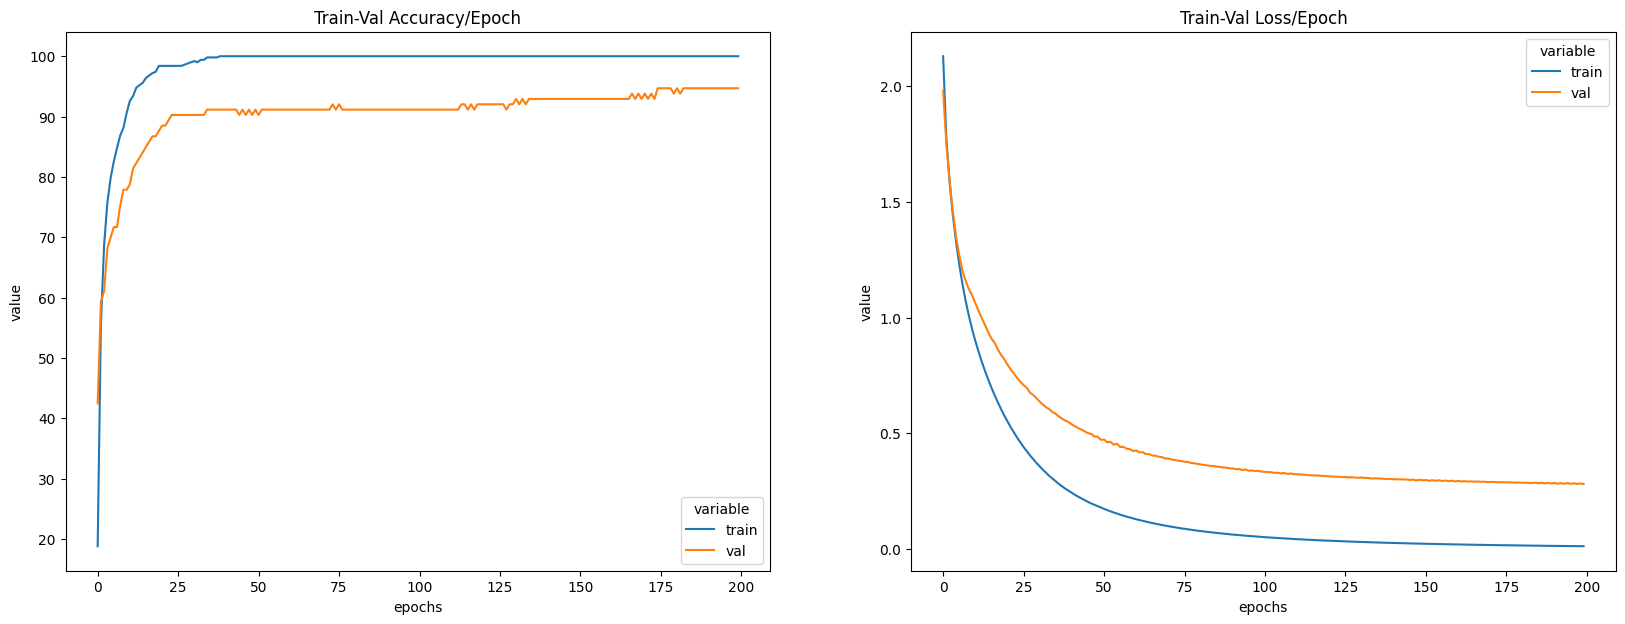

In [22]:
val_accuracies = []
val_avg = []


for i in range(5):
    print(f'Processing split = {i}...')
    df = adata.obs[[f'split{i}', DONOR]].drop_duplicates()
    train = list(df[df[f'split{i}'] == 'train'][DONOR])
    val = list(df[df[f'split{i}'] == 'val'][DONOR])
    # train data
    x = pd.DataFrame(adata_[adata_.obs_names.isin(train)].X).to_numpy()
    num_of_classes = len(adata_.obs[CONDITION].cat.categories)
    y = adata_[adata_.obs_names.isin(train)].obs[CONDITION].cat.rename_categories(list(range(num_of_classes)))
    y = y.to_numpy()
    print("Train shapes:")
    print(f"x.shape = {x.shape}")
    print(f"y.shape = {y.shape}")
    # val data, later this is called test data because the val data is subset of train
    x_val = pd.DataFrame(adata_[adata_.obs_names.isin(val)].X).to_numpy()
    y_val = adata_[adata_.obs_names.isin(val)].obs[CONDITION].cat.rename_categories(list(range(num_of_classes)))
    y_val = y_val.to_numpy()
    print("Val shapes:")
    print(f"x_val.shape = {x_val.shape}")
    print(f"y_val.shape = {y_val.shape}")
    # fit
    X = x
    Y = y
    n_of_train_samples = int(math.ceil(len(y) * TRAIN_FRACTION))
    train_samples = sample(range(len(y)), n_of_train_samples)
    val_samples = [i for i in range(len(y)) if i not in train_samples]
    X_test = x_val
    y_test = y_val
    X_train = x[train_samples]
    y_train = y[train_samples]
    X_val = x[val_samples]
    y_val = y[val_samples]
    
    # create datasets
    train_dataset = ClassifierDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = ClassifierDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = ClassifierDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())
    
    # create loaders
    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE)
    val_loader = DataLoader(dataset=val_dataset, batch_size=1)
    test_loader = DataLoader(dataset=test_dataset, batch_size=1)
    
    # init model
    model = MulticlassClassification(num_feature = NUM_FEATURES, num_class=NUM_CLASSES)
    # define loss
    criterion = nn.CrossEntropyLoss()
    # define optimizer
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # loss recoder
    accuracy_stats = {
        'train': [],
        "val": []
    }
    loss_stats = {
        'train': [],
        "val": []
    }
    
    # train
    print("Begin training.")
    for e in tqdm(range(1, EPOCHS+1)):

        # TRAINING
        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch, y_train_batch
            optimizer.zero_grad()

            y_train_pred = model(X_train_batch)

            train_loss = criterion(y_train_pred, y_train_batch)
            train_acc = multi_acc(y_train_pred, y_train_batch)

            train_loss.backward()
            optimizer.step()

            train_epoch_loss += train_loss.item()
            train_epoch_acc += train_acc.item()


        # VALIDATION    
        with torch.no_grad():

            val_epoch_loss = 0
            val_epoch_acc = 0

            model.eval()
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch, y_val_batch

                y_val_pred = model(X_val_batch)

                val_loss = criterion(y_val_pred, y_val_batch)
                val_acc = multi_acc(y_val_pred, y_val_batch)

                val_epoch_loss += val_loss.item()
                val_epoch_acc += val_acc.item()

        loss_stats['train'].append(train_epoch_loss/len(train_loader))
        loss_stats['val'].append(val_epoch_loss/len(val_loader))
        accuracy_stats['train'].append(train_epoch_acc/len(train_loader))
        accuracy_stats['val'].append(val_epoch_acc/len(val_loader))


    print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.5f} | Val Loss: {val_epoch_loss/len(val_loader):.5f} | Train Acc: {train_epoch_acc/len(train_loader):.3f}| Val Acc: {val_epoch_acc/len(val_loader):.3f}')
    
    # losses
    # Create dataframes
    train_val_acc_df = pd.DataFrame.from_dict(accuracy_stats).reset_index().melt(id_vars=['index']).rename(columns={"index":"epochs"})
    train_val_loss_df = pd.DataFrame.from_dict(loss_stats).reset_index().melt(id_vars=['index']).rename(columns={"index":"epochs"})
    # Plot the dataframes
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,7))
    sns.lineplot(data=train_val_acc_df, x = "epochs", y="value", hue="variable",  ax=axes[0]).set_title('Train-Val Accuracy/Epoch')
    sns.lineplot(data=train_val_loss_df, x = "epochs", y="value", hue="variable", ax=axes[1]).set_title('Train-Val Loss/Epoch')
    
    # predict
    y_pred_list = []
    with torch.no_grad():
        model.eval()
        for X_batch, _ in test_loader:
            X_batch = X_batch
            y_test_pred = model(X_batch)
            _, y_pred_tags = torch.max(y_test_pred, dim = 1)
            y_pred_list.append(y_pred_tags.cpu().numpy())
    y_pred_list = [a.squeeze().tolist() for a in y_pred_list]
    
    df = classification_report(y_test, y_pred_list, output_dict=True)
    df = pd.DataFrame(df).T
    print('class report')
    print(df)
    
    val_accuracies.append(df["f1-score"]["accuracy"])
    val_avg.append(df["f1-score"]["weighted avg"])
    
    print(f'Accuracy on the test set = {df["f1-score"]["accuracy"]}.')
    print('===========================')
    
print(f"Mean validation accuracy across 5 CV splits for a NN model = {np.mean(np.array(val_accuracies))}.")
print(f"Mean validation weighted avg across 5 CV splits for a NN model = {np.mean(np.array(val_avg))}.")


# Random forest

Adjusted from https://www.datacamp.com/tutorial/random-forests-classifier-python.

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
val_accuracies = []
val_avg = []
for i in range(5):
    print(f'Processing split = {i}...')
    df = adata.obs[[f'split{i}', DONOR]].drop_duplicates()
    train = list(df[df[f'split{i}'] == 'train'][DONOR])
    val = list(df[df[f'split{i}'] == 'val'][DONOR])
    # train data
    x = pd.DataFrame(adata_[adata_.obs_names.isin(train)].X).to_numpy()
    num_of_classes = len(adata_.obs[CONDITION].cat.categories)
    y = adata_[adata_.obs_names.isin(train)].obs[CONDITION].cat.rename_categories(list(range(num_of_classes)))
    y = y.to_numpy()
    print("Train shapes:")
    print(f"x.shape = {x.shape}")
    print(f"y.shape = {y.shape}")
    # val data
    x_val = pd.DataFrame(adata_[adata_.obs_names.isin(val)].X).to_numpy()
    y_val = adata_[adata_.obs_names.isin(val)].obs[CONDITION].cat.rename_categories(list(range(num_of_classes)))
    y_val = y_val.to_numpy()
    print("Val shapes:")
    print(f"x_val.shape = {x_val.shape}")
    print(f"y_val.shape = {y_val.shape}")
    # fit
    X = x
    Y = y
    clf = RandomForestClassifier(n_estimators=5)
    clf.fit(X, Y)
    print(f'Train accuracy = {np.sum(clf.predict(X) == Y)/len(Y)}.')
    y_pred = clf.predict(x_val)
    val_accuracy = np.sum(y_pred == y_val)/len(y_val)
    
    df = classification_report(y_val, y_pred, output_dict=True)
    df = pd.DataFrame(df).T
    print('class report')
    print(df)
    
    val_accuracies.append(df["f1-score"]["accuracy"])
    val_avg.append(df["f1-score"]["weighted avg"])
    
    val_accuracy = df["f1-score"]["accuracy"]
    
    print(f'Val accuracy = {val_accuracy}.')
    print('===========================')


print(f"Mean validation accuracy across 5 CV splits for a random forest model = {np.mean(np.array(val_accuracies))}.")
print(f"Mean validation weighted avg across 5 CV splits for a random forest model = {np.mean(np.array(val_avg))}.")


Processing split = 0...
Train shapes:
x.shape = (567, 2000)
y.shape = (567,)
Val shapes:
x_val.shape = (142, 2000)
y_val.shape = (142,)
Train accuracy = 0.9770723104056437.
class report
              precision    recall  f1-score     support
0              1.000000  0.666667  0.800000    3.000000
1              0.666667  0.500000  0.571429    8.000000
2              0.687500  0.846154  0.758621   13.000000
3              0.666667  0.666667  0.666667    6.000000
4              0.500000  0.250000  0.333333    4.000000
5              0.843750  0.964286  0.900000   84.000000
6              0.200000  0.333333  0.250000    3.000000
7              1.000000  0.473684  0.642857   19.000000
8              0.000000  0.000000  0.000000    2.000000
accuracy       0.795775  0.795775  0.795775    0.795775
macro avg      0.618287  0.522310  0.546990  142.000000
weighted avg   0.801027  0.795775  0.779797  142.000000
Val accuracy = 0.795774647887324.
Processing split = 1...
Train shapes:
x.shape = (567

/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels w

Train shapes:
x.shape = (567, 2000)
y.shape = (567,)
Val shapes:
x_val.shape = (142, 2000)
y_val.shape = (142,)
Train accuracy = 0.9770723104056437.
class report
              precision    recall  f1-score     support
0              0.333333  0.250000  0.285714    4.000000
1              0.428571  0.750000  0.545455    4.000000
2              0.800000  0.571429  0.666667   14.000000
3              0.750000  0.428571  0.545455    7.000000
4              1.000000  0.500000  0.666667    4.000000
5              0.803922  0.911111  0.854167   90.000000
6              0.000000  0.000000  0.000000    4.000000
7              0.444444  0.333333  0.380952   12.000000
8              0.500000  0.333333  0.400000    3.000000
accuracy       0.732394  0.732394  0.732394    0.732394
macro avg      0.562252  0.453086  0.482786  142.000000
weighted avg   0.723126  0.732394  0.716826  142.000000
Val accuracy = 0.7323943661971831.
Processing split = 3...
Train shapes:
x.shape = (567, 2000)
y.shape = (567,

/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels w

Train accuracy = 0.9735915492957746.
class report
              precision    recall  f1-score     support
0              0.333333  0.250000  0.285714    4.000000
1              1.000000  0.600000  0.750000    5.000000
2              0.666667  0.625000  0.645161   16.000000
3              0.636364  0.636364  0.636364   11.000000
4              1.000000  0.800000  0.888889    5.000000
5              0.804124  0.962963  0.876404   81.000000
6              0.000000  0.000000  0.000000    5.000000
7              1.000000  0.700000  0.823529   10.000000
8              1.000000  0.250000  0.400000    4.000000
accuracy       0.787234  0.787234  0.787234    0.787234
macro avg      0.715610  0.536036  0.589562  141.000000
weighted avg   0.766908  0.787234  0.762297  141.000000
Val accuracy = 0.7872340425531915.
Mean validation accuracy across 5 CV splits for a random forest model = 0.7687144141444411.
Mean validation weighted avg across 5 CV splits for a random forest model = 0.749402644445281.


/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels w